In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def exact(t):
    return 10/(1 + ((10 - 1)/1)*np.exp(-0.8*t))

def function(t,y):
    return 0.8*y*(1 - y/10)

In [21]:
def euler_explicito(y0,h,ti,tf,function):
    N = int(np.ceil(tf - ti) / h)
    y = np.zeros(N + 1)
    t = np.zeros(N + 1)
    y[0] = y0
    for i in range(N):
        t[i + 1] = t[i] + h
        y[i + 1] = t[i] + h*function(t[i],y[i])
    return t,y


In [22]:
def heun(y0,h,ti,tf,function):
    N = int(np.ceil(tf - ti) / h)
    y = np.zeros(N + 1)
    t = np.zeros(N + 1)
    y[0] = y0
    for i in range(N):
        t[i  + 1] = t[i] + h
        k1 = function(t[i], y[i])
        y_m = y[i] + h*k1
        k2 = function(t[i + 1], y_m)
        k = (k1 + k2) / 2
        y[i + 1] = y[i] + h*k
    return t,y

def ponto_medio(y0,h,ti,tf,function):
    N = int(np.ceil(tf - ti) / h)
    y = np.zeros(N + 1)
    t = np.zeros(N + 1)
    y[0] = y0
    for i in range(N):
            t[i + 1] = t[i] + h
            k1 = function(t[i],y[i])
            y_m = y[i] + (h/2) * k1
            k2 = function(t[i] + h/2, y_m)
            k = k2
            y[i + 1] = y[i] + h*k
    return t,y


In [23]:
h = [2,1,0.5,0.25]

In [24]:
def erro_l2(y_aprox,h,t):
      error = np.zeros(len(h))
      for k in range(len(h)):
          e = 0
          for i in range(len(t)):
                e += h[k]*((exact(t[i]) - y_aprox[i])**2)
          error[k] = e**(1/2)
      return error

In [25]:
t,y_heun = heun(1,2,0,10,function)
t,y_euler = euler_explicito(1,2,0,10,function)
t,y_pm = ponto_medio(1,2,0,10,function)
y_exact = exact(t)

In [26]:
print("Erro L2 (Euler): ", erro_l2(y_euler,h,t))
print("Erro L2 (Heun): ",erro_l2(y_heun,h,t))
print("Erro L2 (Ponto médio): ", erro_l2(y_pm,h,t))

Erro L2 (Euler):  [6.18740934 4.3751591  3.09370467 2.18757955]
Erro L2 (Heun):  [2.36679293 1.67357533 1.18339646 0.83678766]
Erro L2 (Ponto médio):  [1.08217967 0.76521658 0.54108983 0.38260829]


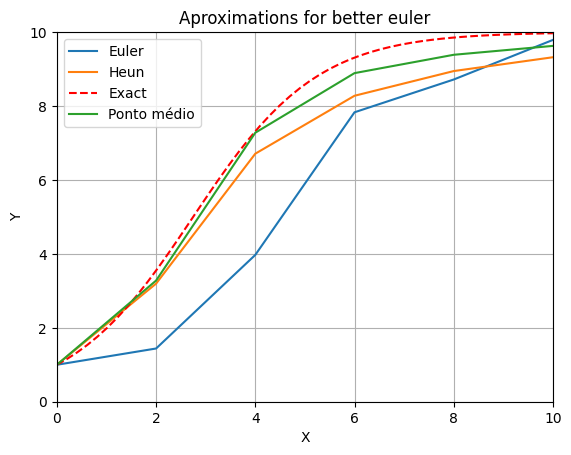

In [31]:
t_exact = np.linspace(0,10)
plt.figure()
plt.plot(t,y_euler, label = "Euler")
plt.plot(t,y_heun, label = "Heun")
plt.plot(t_exact,exact(t_exact), label = "Exact", linestyle = "--", color = 'red')
plt.plot(t,y_pm, label = "Ponto médio")
plt.axis([0,10,0,10])
plt.grid()
plt.title("Aproximations for better euler")
plt.xlabel("X")
plt.ylabel("Y")
plt.savefig("Aproximations")
plt.legend()
plt.show()